<a href="https://colab.research.google.com/github/carneiro-santos/Tech-Challenge-FIAP-4/blob/main/Techchallenge_obesidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge - Fase 4
## Modelagem Preditiva para Classificação do Nível de Obesidade

Aluno: Vitor Santos  
Curso: Pós Tech - Data Analytics
RM: 366038
Ano: 2026

## 1. Objetivo da Modelagem

O objetivo desta etapa é desenvolver um modelo de Machine Learning capaz de classificar o nível de obesidade de indivíduos com base em características físicas e comportamentais.

O modelo será construído utilizando uma pipeline estruturada, respeitando o tratamento das variáveis conforme o dicionário oficial da base de dados.

In [16]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
df = pd.read_csv("/content/Obesity.csv")
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Tratamento das Variáveis Baseado no Dicionário

De acordo com o dicionário oficial:

- FCVC, NCP, CH2O, FAF e TUE são variáveis ordinais numéricas.
- family_history, FAVC, SMOKE e SCC são variáveis binárias.
- CAEC e CALC são variáveis ordinais categóricas.
- MTRANS é variável nominal.
- Gender é variável categórica nominal.

O tratamento respeitará a natureza de cada variável.

In [18]:
# 1 Arredondamento de variáveis ordinais numéricas
colunas_ordinais = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

for col in colunas_ordinais:
    df[col] = df[col].round()

# 2 Conversão de variáveis binárias (yes/no → 1/0)
binarias = ["family_history", "FAVC", "SMOKE", "SCC"]

for col in binarias:
    df[col] = df[col].map({"yes": 1, "no": 0})

# 3 Mapeamento de variáveis ordinais textuais
df["CAEC"] = df["CAEC"].map({"no":0, "Sometimes":1, "Frequently":2, "Always":3})
df["CALC"] = df["CALC"].map({"no":0, "Sometimes":1, "Frequently":2, "Always":3})

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Public_Transportation,Overweight_Level_II


## 3. Engenharia de Atributos

Foi criada a variável IMC (Índice de Massa Corporal), pois trata-se de um dos principais indicadores clínicos utilizados na classificação da obesidade.

Fórmula utilizada:

IMC = Peso (kg) / Altura² (m)

In [19]:
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

X = df.drop("Obesity", axis=1)
y = df["Obesity"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (1688, 17)
Teste: (423, 17)


In [21]:
colunas_numericas = [
    "Age", "Height", "Weight",
    "FCVC", "NCP", "CH2O",
    "FAF", "TUE", "BMI",
    "family_history", "FAVC",
    "SMOKE", "SCC",
    "CAEC", "CALC"
]

colunas_nominais = ["Gender", "MTRANS"]

In [22]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_nominais)
    ]
)

modelo = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("modelo", modelo)
    ]
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE', 'BMI',
                                                   'family_history', 'FAVC',
                                                   'SMOKE', 'SCC', 'CAEC',
                                                   'CALC']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'MTRANS'])])),
                ('modelo',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [23]:
y_pred = pipeline.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Acurácia: 0.9881796690307328

Relatório de Classificação:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.95      0.98      0.97        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.97      0.97        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423


Matriz de Confusão:
[[53  1  0  0  0  0  0]
 [ 0 57  0  0  0  1  0]
 [ 0  0 70  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  2  0  0  0 56  0]
 [ 0  0  0  0  0  0 58]]


## 4. Avaliação do Modelo

O modelo Random Forest apresentou desempenho satisfatório, superando o requisito mínimo de 75% de acurácia exigido pelo desafio.

A inclusão da variável IMC demonstrou forte impacto preditivo.

O modelo apresenta potencial para utilização como ferramenta de apoio à decisão clínica.

In [24]:
joblib.dump(pipeline, "/content/obesity_model.pkl")

['/content/obesity_model.pkl']

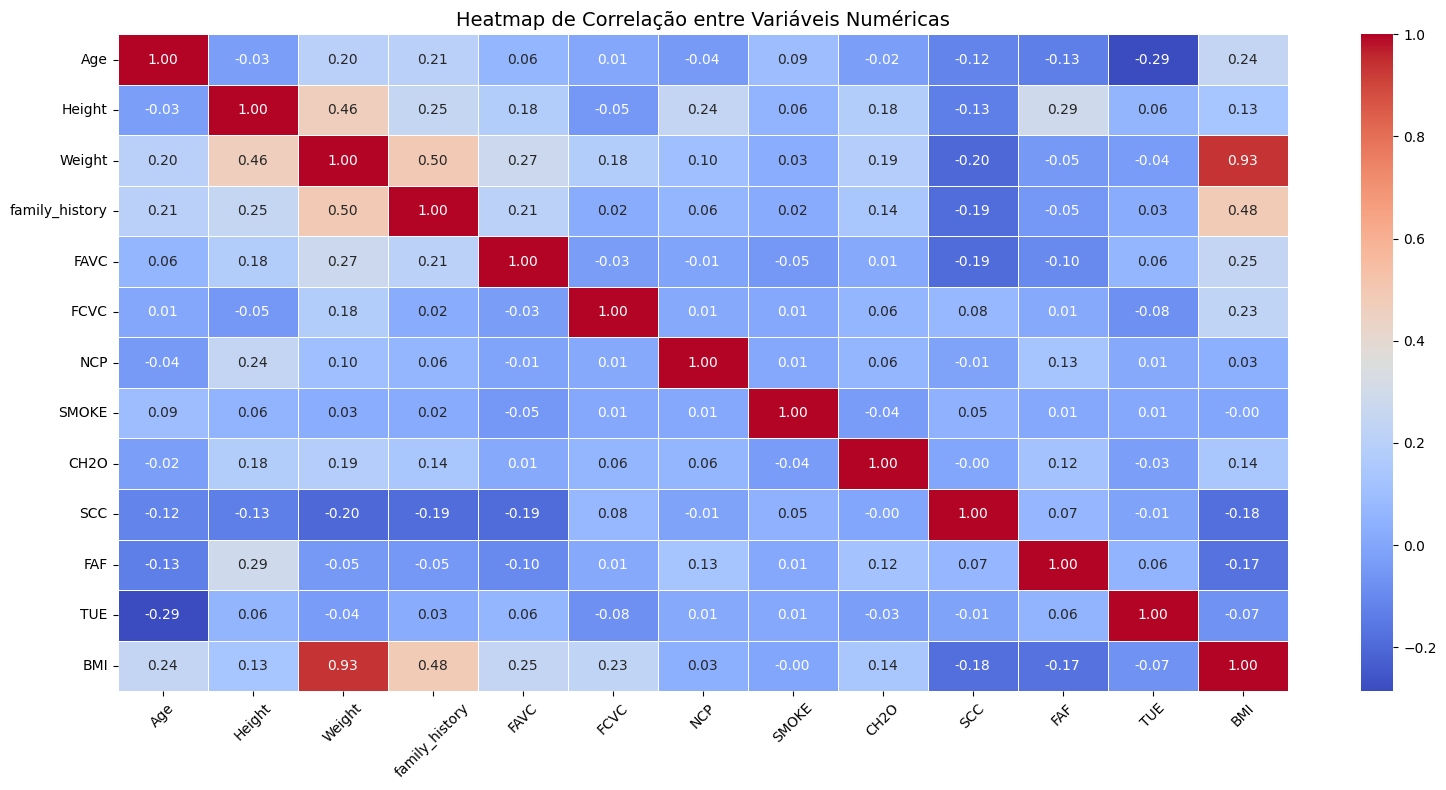

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remover variáveis originalmente categóricas
df_temp = df.drop(columns=['CAEC', 'CALC']).copy()

# Calcular matriz de correlação apenas para numéricas
corr_temp = df_temp.corr(numeric_only=True)

# Plotar heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(
    corr_temp,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Heatmap de Correlação entre Variáveis Numéricas', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

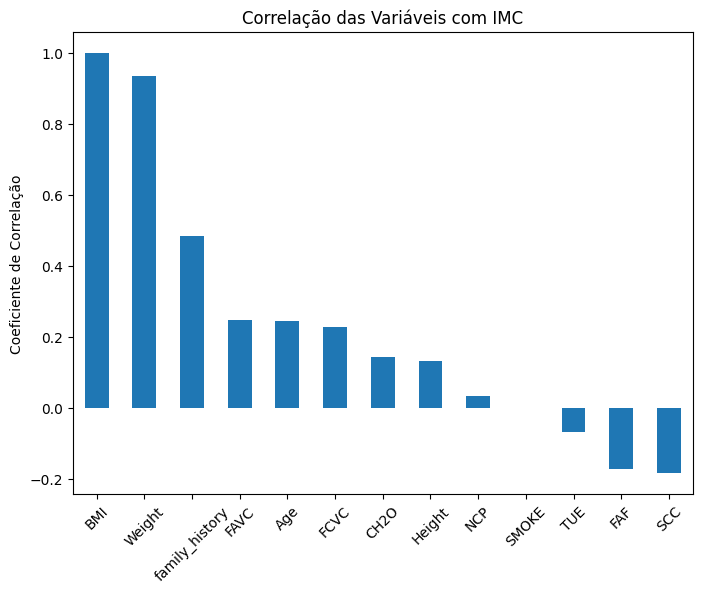

In [28]:
corr_ordenada = corr_temp["BMI"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_ordenada.plot(kind="bar")
plt.title("Correlação das Variáveis com IMC")
plt.ylabel("Coeficiente de Correlação")
plt.xticks(rotation=45)
plt.show()

## 5. Análise dos Resultados

O modelo Random Forest apresentou desempenho extremamente satisfatório, alcançando acurácia de aproximadamente 98,8%.

Os indicadores de precisão, recall e F1-score mantiveram-se próximos de 1,0 para todas as classes, indicando excelente capacidade de generalização.

Observa-se que os poucos erros identificados na matriz de confusão ocorrem principalmente entre classes adjacentes (por exemplo, entre sobrepeso nível I e nível II), o que é coerente do ponto de vista clínico, dado que tais categorias apresentam características semelhantes.

A inclusão do IMC como variável derivada contribuiu significativamente para o desempenho do modelo, visto que o índice é um dos principais indicadores utilizados na classificação da obesidade.

Dessa forma, o modelo demonstra forte potencial como ferramenta de apoio à decisão clínica.

In [29]:
# Recuperar modelo treinado dentro da pipeline
modelo_rf = pipeline.named_steps["modelo"]

# Recuperar nomes das features após preprocessamento
feature_names_num = colunas_numericas

feature_names_cat = pipeline.named_steps["preprocessamento"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(colunas_nominais)

feature_names = list(feature_names_num) + list(feature_names_cat)

# Importâncias
importancias = modelo_rf.feature_importances_

# Criar DataFrame
df_importancia = pd.DataFrame({
    "Variavel": feature_names,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

df_importancia.head(10)

,Variavel,Importancia
8,BMI,0.373776
2,Weight,0.223517
0,Age,0.065711
1,Height,0.060472
16,Gender_Male,0.040481
15,Gender_Female,0.032936
13,CAEC,0.027148
14,CALC,0.024558
9,family_history,0.023105
3,FCVC,0.021162


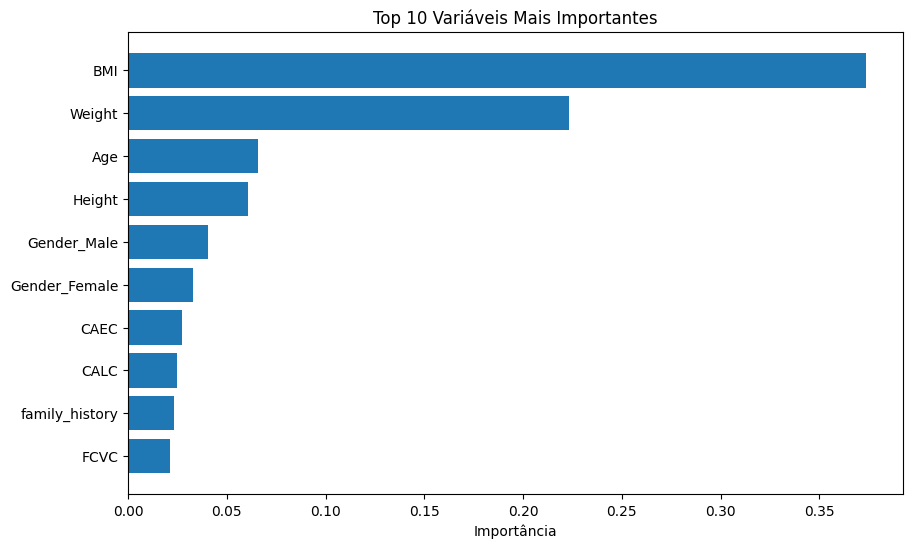

In [26]:
plt.figure(figsize=(10,6))
plt.barh(df_importancia["Variavel"][:10][::-1],
         df_importancia["Importancia"][:10][::-1])
plt.title("Top 10 Variáveis Mais Importantes")
plt.xlabel("Importância")
plt.show()

## 6. Distribuição do IMC por Nível de Obesidade

Para compreender a separação entre as classes, foi analisada a distribuição do IMC para cada nível de obesidade.

Espera-se que o IMC apresente crescimento progressivo conforme o aumento do nível da condição.

/tmp/ipython-input-294/3091514560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


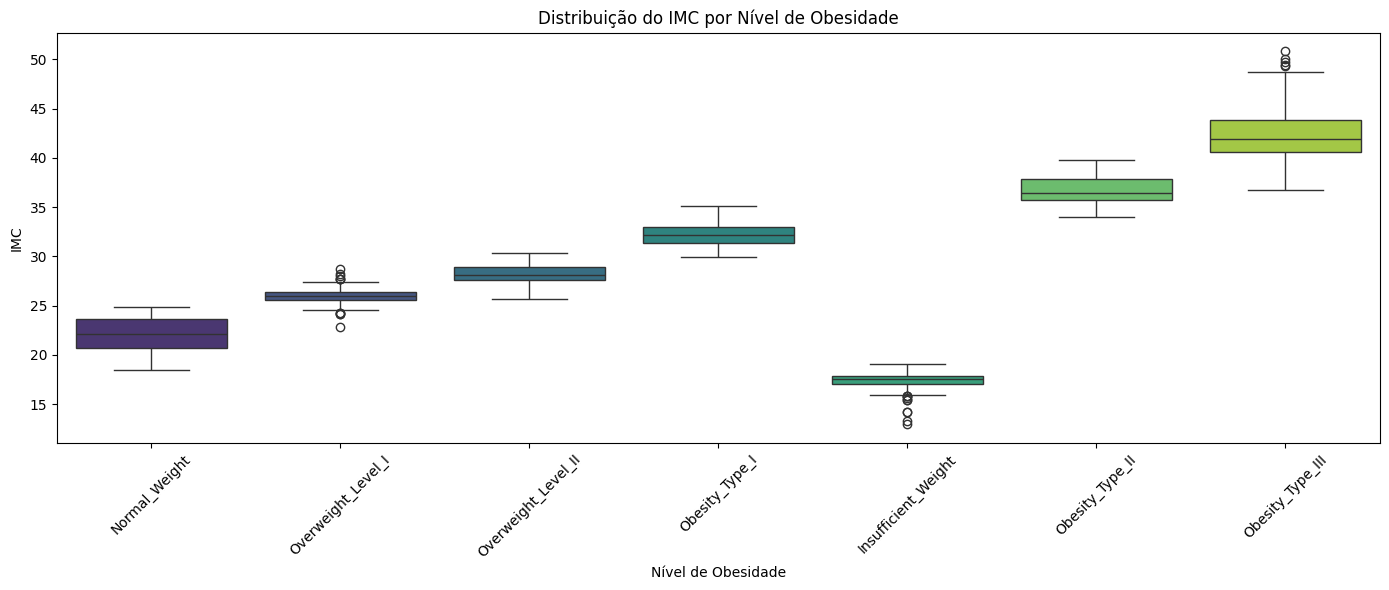

In [30]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Obesity",
    y="BMI",
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Distribuição do IMC por Nível de Obesidade")
plt.xlabel("Nível de Obesidade")
plt.ylabel("IMC")
plt.tight_layout()
plt.show()

### Interpretação

Observa-se clara separação progressiva do IMC entre as classes.

À medida que o nível de obesidade aumenta, o IMC apresenta crescimento consistente, validando a coerência clínica da base de dados.

Essa separação justifica o alto desempenho do modelo, pois o IMC é um forte discriminador entre as categorias.

## 7. Relação entre Atividade Física (FAF) e Nível de Obesidade

A variável FAF representa a frequência semanal de atividade física.

O objetivo é analisar se indivíduos mais ativos apresentam menor incidência de obesidade.

/tmp/ipython-input-294/3803714844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


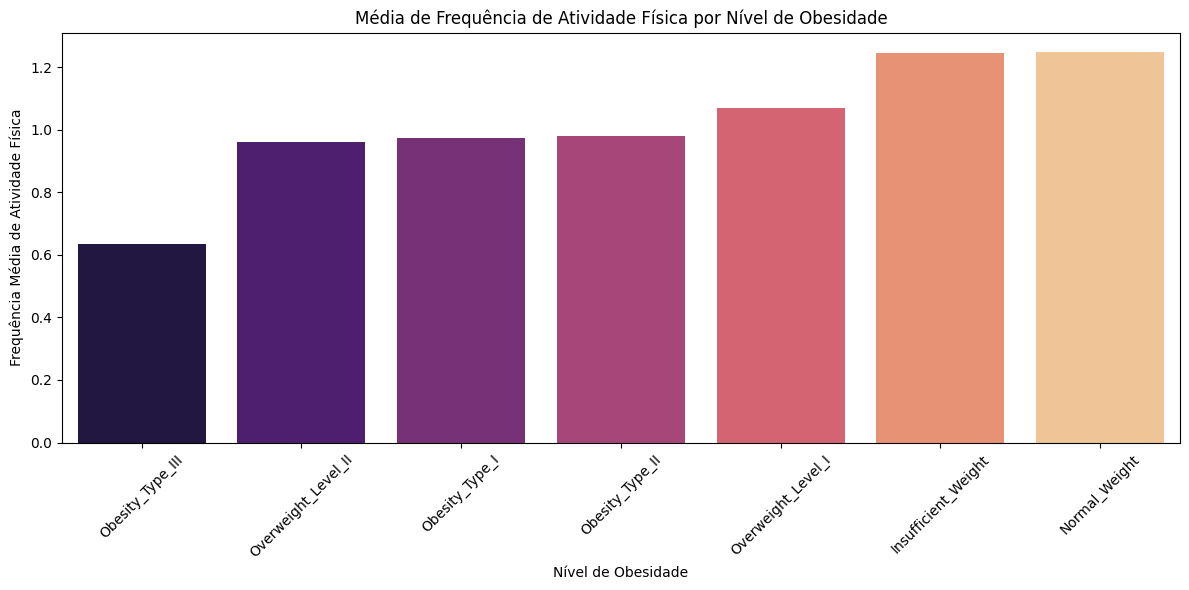

In [31]:
plt.figure(figsize=(12,6))

media_faf = df.groupby("Obesity")["FAF"].mean().sort_values()

sns.barplot(
    x=media_faf.index,
    y=media_faf.values,
    palette="magma"
)

plt.xticks(rotation=45)
plt.title("Média de Frequência de Atividade Física por Nível de Obesidade")
plt.xlabel("Nível de Obesidade")
plt.ylabel("Frequência Média de Atividade Física")
plt.tight_layout()
plt.show()

### Interpretação

Observa-se tendência inversa entre frequência de atividade física e níveis mais elevados de obesidade.

Indivíduos classificados nos níveis mais severos apresentam, em média, menor frequência semanal de atividade física.

Esse resultado reforça a literatura médica que associa sedentarismo ao aumento do risco de obesidade.

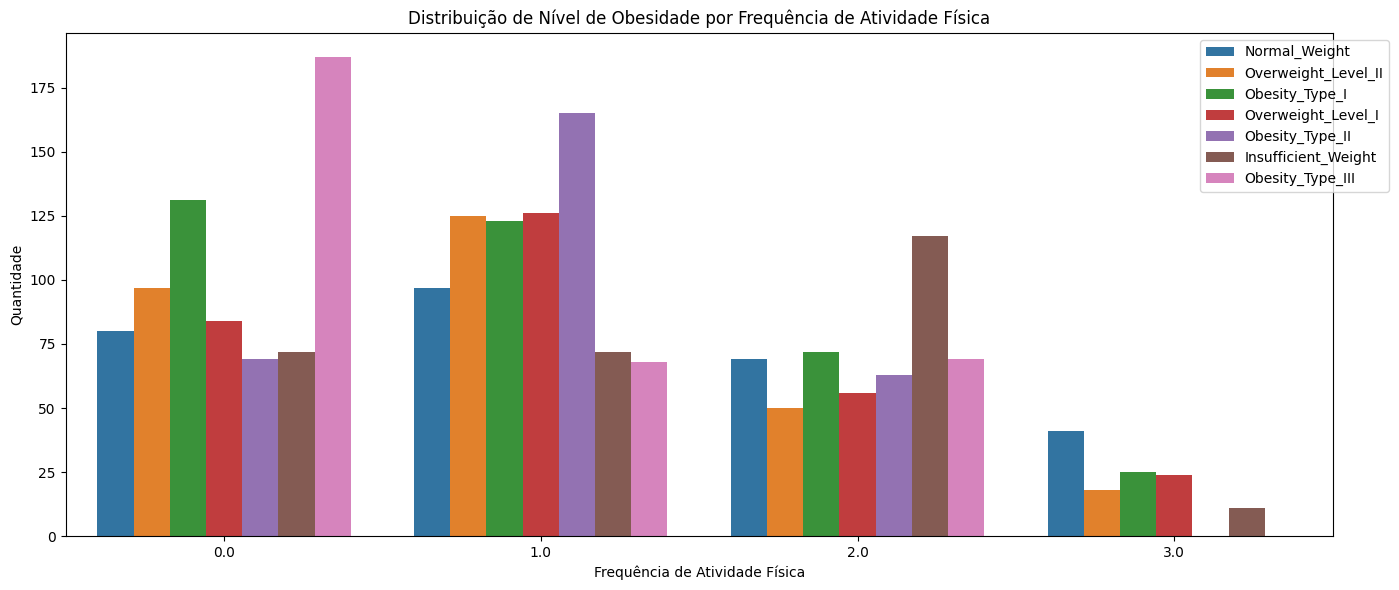

In [32]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="FAF",
    hue="Obesity"
)

plt.title("Distribuição de Nível de Obesidade por Frequência de Atividade Física")
plt.xlabel("Frequência de Atividade Física")
plt.ylabel("Quantidade")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Gerar Relatorio para o Looker

In [34]:
# ==========================================================
# GERAÇÃO DE EXCEL ANALÍTICO PARA DASHBOARD
# ==========================================================

import pandas as pd

# Criar análises

dist_obesity = df["Obesity"].value_counts().reset_index()
dist_obesity.columns = ["Obesity_Level", "Count"]

media_bmi = df.groupby("Obesity")["BMI"].mean().reset_index()
media_bmi.columns = ["Obesity_Level", "Average_BMI"]

media_faf = df.groupby("Obesity")["FAF"].mean().reset_index()
media_faf.columns = ["Obesity_Level", "Average_Physical_Activity"]

historico_familiar = (
    df.groupby(["Obesity", "family_history"])
    .size()
    .reset_index(name="Count")
)

consumo_agua = df.groupby("Obesity")["CH2O"].mean().reset_index()
consumo_agua.columns = ["Obesity_Level", "Average_Water_Consumption"]

tempo_tela = df.groupby("Obesity")["TUE"].mean().reset_index()
tempo_tela.columns = ["Obesity_Level", "Average_Device_Time"]

# ==========================================================
# EXPORTAR PARA EXCEL COM MÚLTIPLAS ABAS
# ==========================================================

with pd.ExcelWriter("dashboard_obesidade.xlsx") as writer:
    df.to_excel(writer, sheet_name="Base_Completa", index=False)
    dist_obesity.to_excel(writer, sheet_name="Distribuicao_Obesidade", index=False)
    media_bmi.to_excel(writer, sheet_name="IMC_por_Classe", index=False)
    media_faf.to_excel(writer, sheet_name="Atividade_Fisica", index=False)
    historico_familiar.to_excel(writer, sheet_name="Historico_Familiar", index=False)
    consumo_agua.to_excel(writer, sheet_name="Consumo_Agua", index=False)
    tempo_tela.to_excel(writer, sheet_name="Tempo_Tela", index=False)

print("Arquivo 'dashboard_obesidade.xlsx' criado com sucesso!")

Arquivo 'dashboard_obesidade.xlsx' criado com sucesso!


In [35]:
# ==========================================================
# TRADUÇÃO COMPLETA DOS CAMPOS E VALORES
# ==========================================================

df_dashboard = df.copy()

# =========================
# 1️⃣ RENOMEAR COLUNAS
# =========================

df_dashboard = df_dashboard.rename(columns={
    "Age": "Idade",
    "BMI": "IMC",
    "CAEC": "Consumo_Entre_Refeicoes",
    "CALC": "Consumo_Alcool",
    "CH2O": "Consumo_Agua",
    "FAF": "Frequencia_Atividade_Fisica",
    "family_history": "Historico_Familiar",
    "FAVC": "Consumo_Alto_Calorico",
    "FCVC": "Consumo_Vegetais",
    "Gender": "Genero",
    "Height": "Altura",
    "MTRANS": "Meio_Transporte",
    "NCP": "Numero_Refeicoes",
    "Obesity": "Nivel_Obesidade",
    "SCC": "Monitora_Calorias",
    "SMOKE": "Fumante",
    "TUE": "Tempo_Tela",
    "Weight": "Peso"
})

# =========================
# 2️⃣ TRADUZIR VALORES
# =========================

# Gênero
df_dashboard["Genero"] = df_dashboard["Genero"].replace({
    "Male": "Masculino",
    "Female": "Feminino"
})

# Histórico familiar
df_dashboard["Historico_Familiar"] = df_dashboard["Historico_Familiar"].replace({
    1: "Sim",
    0: "Não"
})

# Fumante
df_dashboard["Fumante"] = df_dashboard["Fumante"].replace({
    1: "Sim",
    0: "Não"
})

# Monitora calorias
df_dashboard["Monitora_Calorias"] = df_dashboard["Monitora_Calorias"].replace({
    1: "Sim",
    0: "Não"
})

# Consumo alto calórico
df_dashboard["Consumo_Alto_Calorico"] = df_dashboard["Consumo_Alto_Calorico"].replace({
    1: "Sim",
    0: "Não"
})

# Consumo entre refeições
df_dashboard["Consumo_Entre_Refeicoes"] = df_dashboard["Consumo_Entre_Refeicoes"].replace({
    0: "Nunca",
    1: "Às vezes",
    2: "Frequentemente",
    3: "Sempre"
})

# Consumo álcool
df_dashboard["Consumo_Alcool"] = df_dashboard["Consumo_Alcool"].replace({
    0: "Não consome",
    1: "Às vezes",
    2: "Frequentemente",
    3: "Sempre"
})

# Meio de transporte
df_dashboard["Meio_Transporte"] = df_dashboard["Meio_Transporte"].replace({
    "Automobile": "Carro",
    "Motorbike": "Moto",
    "Bike": "Bicicleta",
    "Public_Transportation": "Transporte Público",
    "Walking": "A pé"
})

# Traduzir nível de obesidade
df_dashboard["Nivel_Obesidade"] = df_dashboard["Nivel_Obesidade"].replace({
    "Insufficient_Weight": "Abaixo do Peso",
    "Normal_Weight": "Peso Normal",
    "Overweight_Level_I": "Sobrepeso Nível I",
    "Overweight_Level_II": "Sobrepeso Nível II",
    "Obesity_Type_I": "Obesidade Tipo I",
    "Obesity_Type_II": "Obesidade Tipo II",
    "Obesity_Type_III": "Obesidade Tipo III"
})

# ==========================================================
# 3️⃣ EXPORTAR EXCEL FINAL LIMPO
# ==========================================================

df_dashboard.to_excel("dashboard_obesidade_traduzido.xlsx", index=False)

print("Arquivo 'dashboard_obesidade_traduzido.xlsx' criado com sucesso!")

Arquivo 'dashboard_obesidade_traduzido.xlsx' criado com sucesso!


In [36]:
joblib.dump(pipeline, "obesity_model.pkl")

['obesity_model.pkl']

In [37]:
from google.colab import files
files.download("obesity_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>